# Разведочный анализ данных бразильского маркетплейса Olist

**Цель:** Провести разведочный анализ продаж интернет-магазина Olist: выявить сезонность, определить топ-категории товаров, проанализировать распределение сумм заказов


**Датасет:** Brazilian E-Commerce Public Dataset by Olist

**Источник данных:** https://www.kaggle.com/datasets/olistbr/brazilian-ecommerce?select=olist_orders_dataset.csv

In [ ]:
import pandas as pd
print(pd.__version__)

2.2.2


In [ ]:
orders = pd.read_csv('olist_orders_dataset.csv')
items = pd.read_csv('olist_order_items_dataset.csv')
products = pd.read_csv('olist_products_dataset.csv')

In [ ]:
print(f"orders: {orders.shape}")
print(f"items: {items.shape}")
print(f"products: {products.shape}")

orders: (99441, 8)
items: (112650, 7)
products: (36855, 9)


In [ ]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype 
---  ------                         --------------  ----- 
 0   order_id                       99441 non-null  object
 1   customer_id                    99441 non-null  object
 2   order_status                   99441 non-null  object
 3   order_purchase_timestamp       99441 non-null  object
 4   order_approved_at              99281 non-null  object
 5   order_delivered_carrier_date   97658 non-null  object
 6   order_delivered_customer_date  96476 non-null  object
 7   order_estimated_delivery_date  99441 non-null  object
dtypes: object(8)
memory usage: 6.1+ MB


In [ ]:
orders.isnull().sum()

,0
order_id,0
customer_id,0
order_status,0
order_purchase_timestamp,0
order_approved_at,160
order_delivered_carrier_date,1783
order_delivered_customer_date,2965
order_estimated_delivery_date,0


In [ ]:
# проверка дубликатов в orders
print("Дубликаты в orders (по всем колонкам):", orders.duplicated().sum())
print("Дубликаты по order_id:", orders['order_id'].duplicated().sum())

Дубликаты в orders (по всем колонкам): 0
Дубликаты по order_id: 0


In [ ]:
# преобразуем типы данных дат
orders['order_purchase_timestamp'] = pd.to_datetime(orders['order_purchase_timestamp'], errors = 'coerce')
orders['order_approved_at'] = pd.to_datetime(orders['order_approved_at'], errors = 'coerce')
orders['order_delivered_carrier_date'] = pd.to_datetime(orders['order_delivered_carrier_date'], errors = 'coerce')
orders['order_delivered_customer_date'] = pd.to_datetime(orders['order_delivered_customer_date'], errors = 'coerce')
orders['order_estimated_delivery_date'] = pd.to_datetime(orders['order_estimated_delivery_date'], errors = 'coerce')

In [ ]:
orders.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype         
---  ------                         --------------  -----         
 0   order_id                       99441 non-null  object        
 1   customer_id                    99441 non-null  object        
 2   order_status                   99441 non-null  object        
 3   order_purchase_timestamp       99441 non-null  datetime64[ns]
 4   order_approved_at              99281 non-null  datetime64[ns]
 5   order_delivered_carrier_date   97658 non-null  datetime64[ns]
 6   order_delivered_customer_date  96476 non-null  datetime64[ns]
 7   order_estimated_delivery_date  99441 non-null  datetime64[ns]
dtypes: datetime64[ns](5), object(3)
memory usage: 6.1+ MB


In [ ]:
items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [ ]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype  
---  ------               --------------   -----  
 0   order_id             112650 non-null  object 
 1   order_item_id        112650 non-null  int64  
 2   product_id           112650 non-null  object 
 3   seller_id            112650 non-null  object 
 4   shipping_limit_date  112650 non-null  object 
 5   price                112650 non-null  float64
 6   freight_value        112650 non-null  float64
dtypes: float64(2), int64(1), object(4)
memory usage: 6.0+ MB


In [ ]:
# проверка дубликатов в items
print("\nДубликаты в items (по всем колонкам):", items.duplicated().sum())
# в items дубликаты допустимы, так как один заказ может содержать несколько товаров
print("Дубликаты по связке (order_id, order_item_id):", items[['order_id', 'order_item_id']].duplicated().sum())


Дубликаты в items (по всем колонкам): 0
Дубликаты по связке (order_id, order_item_id): 0


In [ ]:
# преобразуем тип данных дат
items['shipping_limit_date'] = pd.to_datetime(items['shipping_limit_date'], errors='coerce')

In [ ]:
items.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112650 entries, 0 to 112649
Data columns (total 7 columns):
 #   Column               Non-Null Count   Dtype         
---  ------               --------------   -----         
 0   order_id             112650 non-null  object        
 1   order_item_id        112650 non-null  int64         
 2   product_id           112650 non-null  object        
 3   seller_id            112650 non-null  object        
 4   shipping_limit_date  112650 non-null  datetime64[ns]
 5   price                112650 non-null  float64       
 6   freight_value        112650 non-null  float64       
dtypes: datetime64[ns](1), float64(2), int64(1), object(3)
memory usage: 6.0+ MB


In [ ]:
products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 36855 entries, 0 to 36854
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  36855 non-null  object 
 1   product_category_name       36167 non-null  object 
 2   product_name_lenght         36167 non-null  float64
 3   product_description_lenght  36167 non-null  float64
 4   product_photos_qty          36167 non-null  float64
 5   product_weight_g            36853 non-null  float64
 6   product_length_cm           36853 non-null  float64
 7   product_height_cm           36853 non-null  float64
 8   product_width_cm            36852 non-null  float64
dtypes: float64(7), object(2)
memory usage: 2.5+ MB


In [ ]:
# проверка дубликатов в products
print("\nДубликаты в products (по всем колонкам):", products.duplicated().sum())
print("Дубликаты по product_id:", products['product_id'].duplicated().sum())


Дубликаты в products (по всем колонкам): 3903
Дубликаты по product_id: 3903


In [ ]:
# удаляем дубликаты, оставляя первое вхождение
len_products = len(products)
products = products.drop_duplicates(subset='product_id', keep='first')
print(f"Было строк: {len_products}, стало: {len(products)}")

Было строк: 36855, стало: 32952


In [ ]:
# преобразуем тип даных чисел в челочисленный
products['product_name_lenght'] = products['product_name_lenght'].astype('Int64')
products['product_description_lenght'] = products['product_description_lenght'].astype('Int64')
products['product_photos_qty'] = products['product_photos_qty'].astype('Int64')


In [ ]:
products.info()

<class 'pandas.core.frame.DataFrame'>
Index: 32952 entries, 0 to 32951
Data columns (total 9 columns):
 #   Column                      Non-Null Count  Dtype  
---  ------                      --------------  -----  
 0   product_id                  32952 non-null  object 
 1   product_category_name       32342 non-null  object 
 2   product_name_lenght         32342 non-null  Int64  
 3   product_description_lenght  32342 non-null  Int64  
 4   product_photos_qty          32342 non-null  Int64  
 5   product_weight_g            32950 non-null  float64
 6   product_length_cm           32950 non-null  float64
 7   product_height_cm           32950 non-null  float64
 8   product_width_cm            32949 non-null  float64
dtypes: Int64(3), float64(4), object(2)
memory usage: 2.6+ MB


Создадим таблице orders_items

In [ ]:
orders_items = pd.merge(orders, items, on='order_id', how='inner')
print(f"Размер orders_items: {orders_items.shape}")

Размер orders_items: (112650, 14)


In [ ]:
orders_items.head(10)

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72
5,a4591c265e18cb1dcee52889e2d8acc3,503740e9ca751ccdda7ba28e9ab8f608,delivered,2017-07-09 21:57:05,2017-07-09 22:10:13,2017-07-11 14:58:04,2017-07-26 10:57:55,2017-08-01,1,060cb19345d90064d1015407193c233d,8581055ce74af1daba164fdbd55a40de,2017-07-13 22:10:13,147.90,27.36
6,136cce7faa42fdb2cefd53fdc79a6098,ed0271e0b7da060a393796590e7b737a,invoiced,2017-04-11 12:22:08,2017-04-13 13:25:17,NaT,NaT,2017-05-09,1,a1804276d9941ac0733cfd409f5206eb,dc8798cbf453b7e0f98745e396cc5616,2017-04-19 13:25:17,49.90,16.05
7,6514b8ad8028c9f2cc2374ded245783f,9bdf08b4b3b52b5526ff42d37d47f222,delivered,2017-05-16 13:10:30,2017-05-16 13:22:11,2017-05-22 10:07:46,2017-05-26 12:55:51,2017-06-07,1,4520766ec412348b8d4caa5e8a18c464,16090f2ca825584b5a147ab24aa30c86,2017-05-22 13:22:11,59.99,15.17
8,76c6e866289321a7c93b82b54852dc33,f54a9f0e6b351c431402b8461ea51999,delivered,2017-01-23 18:29:09,2017-01-25 02:50:47,2017-01-26 14:16:31,2017-02-02 14:08:10,2017-03-06,1,ac1789e492dcd698c5c10b97a671243a,63b9ae557efed31d1f7687917d248a8d,2017-01-27 18:29:09,19.90,16.05
9,e69bfb5eb88e0ed6a785585b27e16dbf,31ad1d1b63eb9962463f764d4e6e0c9d,delivered,2017-07-29 11:55:02,2017-07-29 12:05:32,2017-08-10 19:45:24,2017-08-16 17:14:30,2017-08-23,1,9a78fb9862b10749a117f7fc3c31f051,7c67e1448b00f6e969d365cea6b010ab,2017-08-11 12:05:32,149.99,19.77


Добавляем категории товаров (LEFT JOIN)

In [ ]:
products_subset = products[['product_id', 'product_category_name']]
full_data = pd.merge(orders_items, products_subset, on='product_id', how='left')
print(f"Размер full_data: {full_data.shape}")
full_data.head()

Размер full_data: (112650, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,1,87285b34884572647811a353c7ac498a,3504c0cb71d7fa48d967e0e4c94d59d9,2017-10-06 11:07:15,29.99,8.72,utilidades_domesticas
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,1,595fac2a385ac33a80bd5114aec74eb8,289cdb325fb7e7f891c38608bf9e0962,2018-07-30 03:24:27,118.70,22.76,perfumaria
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,1,aa4383b373c6aca5d8797843e5594415,4869f7a5dfa277a7dca6462dcf3b52b2,2018-08-13 08:55:23,159.90,19.22,automotivo
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,1,d0b61bfb1de832b15ba9d266ca96e5b0,66922902710d126a0e7d26b0e3805106,2017-11-23 19:45:59,45.00,27.20,pet_shop
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,1,65266b2da20d04dbe00c5c2d3bb7859e,2c9e548be18521d1c43cde1c582c6de8,2018-02-19 20:31:37,19.90,8.72,papelaria


In [ ]:
full_data.describe()

,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_item_id,shipping_limit_date,price,freight_value
count,112650,112635,111456,110196,112650,112650.000000,112650,112650.000000,112650.000000
mean,2018-01-01 00:09:48.464376320,2018-01-01 11:46:01.497003520,2018-01-05 02:22:56.161642240,2018-01-14 13:25:24.023939328,2018-01-24 20:12:15.531291392,1.197834,2018-01-07 15:36:52.192685312,120.653739,19.990320
min,2016-09-04 21:15:19,2016-09-15 12:16:38,2016-10-08 10:34:01,2016-10-11 13:46:32,2016-10-04 00:00:00,1.000000,2016-09-19 00:15:34,0.850000,0.000000
25%,2017-09-13 19:17:04,2017-09-14 03:06:05,2017-09-18 20:41:02.249999872,2017-09-26 20:09:44.500000,2017-10-05 00:00:00,1.000000,2017-09-20 20:57:27.500000,39.900000,13.080000
50%,2018-01-19 23:02:16,2018-01-20 13:42:05,2018-01-24 18:44:52.500000,2018-02-02 20:57:23,2018-02-16 00:00:00,1.000000,2018-01-26 13:59:35,74.990000,16.260000
75%,2018-05-04 17:30:36.750000128,2018-05-05 03:10:16.500000,2018-05-08 13:20:15,2018-05-15 20:09:21.500000,2018-05-28 00:00:00,1.000000,2018-05-10 14:34:00.750000128,134.900000,21.150000
max,2018-09-03 09:06:57,2018-09-03 17:40:06,2018-09-11 19:48:28,2018-10-17 13:22:46,2018-10-25 00:00:00,21.000000,2020-04-09 22:35:08,6735.000000,409.680000
std,NaN,NaN,NaN,NaN,NaN,0.705124,NaN,183.633928,15.806405


Найдем общую выручку

In [ ]:
# общая выручка
total_revenue = full_data['price'].sum()
print(f"Общая выручка: {total_revenue:,.2f}")

Общая выручка: 13,591,643.70


Посчитаем средний чек

In [ ]:
# средний чек (сумма price по каждому order_id)
order_revenue = full_data.groupby('order_id')['price'].sum()
avg_order_value = order_revenue.mean()
print(f"Средний чек: {avg_order_value:.2f}")

Средний чек: 137.75


Найдем количество уникальных заказов

In [ ]:
# количество уникальных заказов
num_orders = full_data['order_id'].nunique()
print(f"Всего заказов: {num_orders}")

Всего заказов: 98666


 График 1: динамика заказов по месяцам

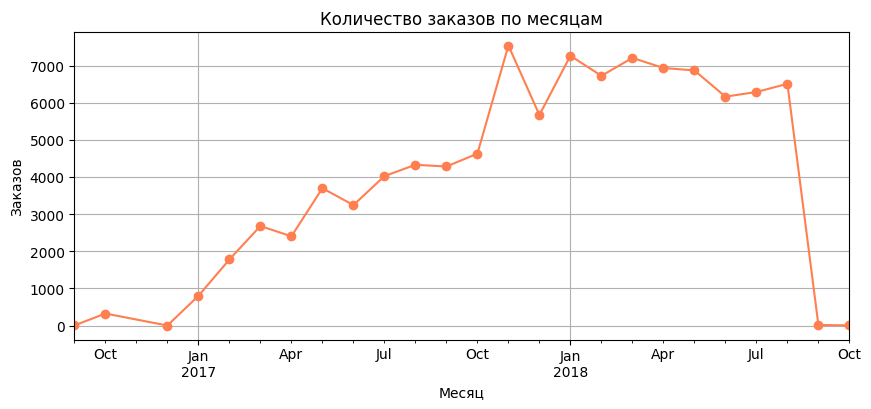

In [ ]:
import matplotlib.pyplot as plt

# создаем колонку с месяцем
orders['month'] = orders['order_purchase_timestamp'].dt.to_period('M')
monthly_orders = orders.groupby('month').size()

plt.figure(figsize=(10,4))
monthly_orders.plot(kind='line', marker='o', color='coral')
plt.title('Количество заказов по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Заказов')
plt.grid(True)
plt.show()



График 2: динамика выручки по месяцам

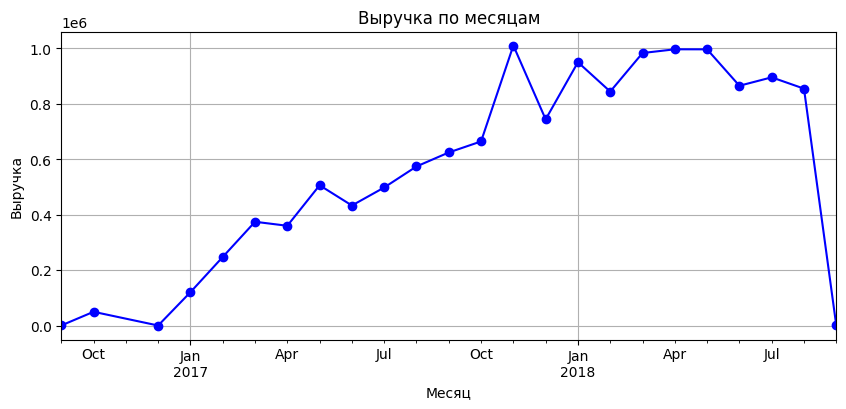

In [ ]:
full_data['month'] = full_data['order_purchase_timestamp'].dt.to_period('M')
monthly_revenue = full_data.groupby('month')['price'].sum()

plt.figure(figsize=(10,4))
monthly_revenue.plot(kind='line', marker='o', color='blue')
plt.title('Выручка по месяцам')
plt.xlabel('Месяц')
plt.ylabel('Выручка')
plt.grid(True)
plt.show()

График 3: топ-10 категорий по выручке

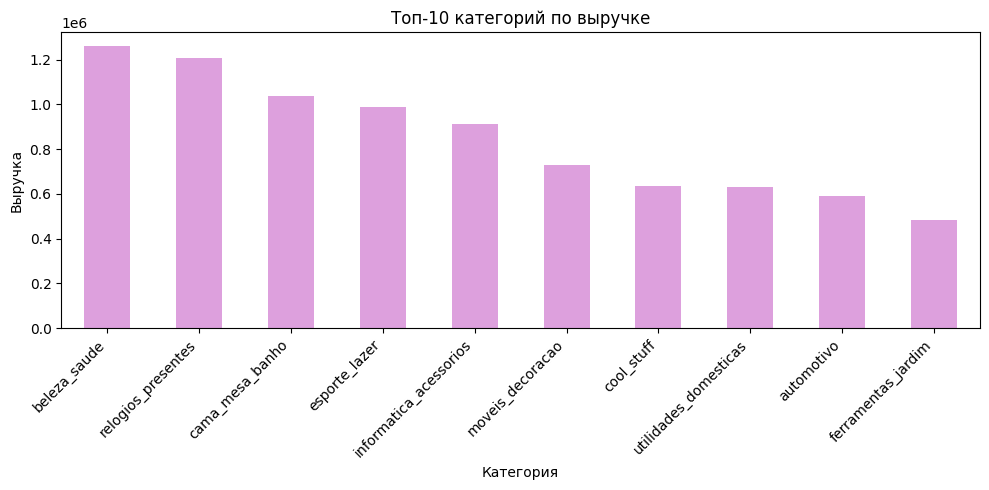

In [ ]:
cat_revenue = full_data.groupby('product_category_name')['price'].sum().sort_values(ascending=False).head(10)

plt.figure(figsize=(10,5))
cat_revenue.plot(kind='bar', color='plum')
plt.title('Топ-10 категорий по выручке')
plt.xlabel('Категория')
plt.ylabel('Выручка')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

График 4: распределение суммы заказов (гистограмма)

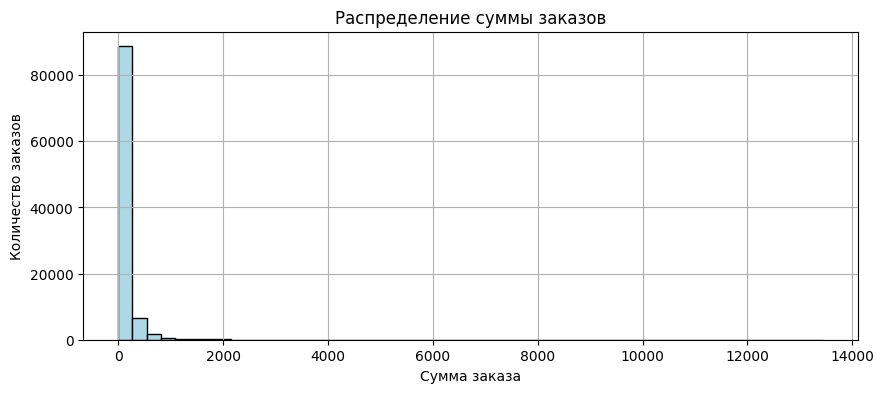

In [ ]:
plt.figure(figsize=(10,4))
order_revenue.hist(bins=50, color='lightblue', edgecolor='black')
plt.title('Распределение суммы заказов')
plt.xlabel('Сумма заказа')
plt.ylabel('Количество заказов')
plt.show()

График 5: распределение суммы заказов (боксплот)

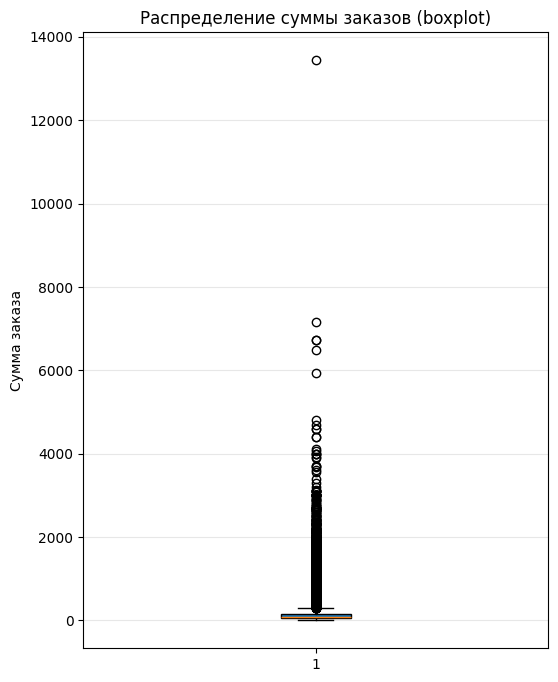

In [ ]:
plt.figure(figsize=(6, 8))
plt.boxplot(order_revenue, vert=True, patch_artist=True)
plt.title('Распределение суммы заказов (boxplot)')
plt.ylabel('Сумма заказа')
plt.grid(True, axis='y', alpha=0.3)
plt.show()

График 6: распределение суммы заказов (без самых курупных 5%)

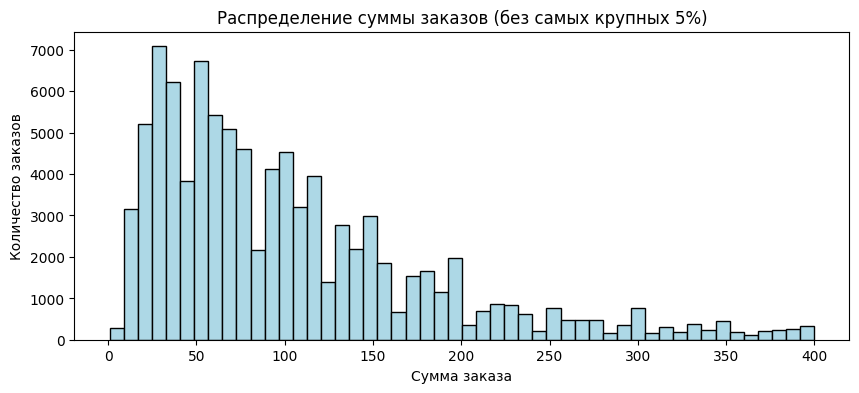

In [ ]:
import numpy as np

# верхняя граница для графика (95% заказов)
upper_limit = order_revenue.quantile(0.95)

plt.figure(figsize=(10,4))
plt.hist(order_revenue[order_revenue <= upper_limit], bins=50, color='lightblue', edgecolor='black')
plt.title('Распределение суммы заказов (без самых крупных 5%)')
plt.xlabel('Сумма заказа')
plt.ylabel('Количество заказов')
plt.show()

# Выводы

- Общая выручка составляет 13 591 643.70 долл., средний чек  — 137.75 долл., всего заказов  —  98 666.
- Наибольшее количество заказов приходится на месяц ноябрь.
- Топ-3 категории по выручке: beleza_saude (красота и здоровье), relogios_presentes (часы и подарки), cama_mesa_banho (постельное бельё, стол, ванна).
- Большинство заказов имеют сумму в диапазоне от 10 до 150 долл.
